<a href="https://colab.research.google.com/github/misun0314/AI-Python/blob/main/%ED%8C%8C%EC%9D%B4%EC%8D%AC_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_%EB%A7%9B%EB%B3%B4%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 한글 폰트 설정
Google Colab에서 한글을 표시하기 위한 폰트 설치 및 설정입니다. 이 셀은 런타임이 재시작될 때마다 실행해야 합니다.

In [ ]:
# 나눔폰트 설치 및 캐시 갱신
!apt-get update -qq > /dev/null
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

# matplotlib 폰트 캐시 삭제 (재시작 없이 적용하기 위해)
import matplotlib as mpl
import shutil, os

cache_dir = mpl.get_cachedir()
shutil.rmtree(cache_dir, ignore_errors=True)
os.makedirs(cache_dir, exist_ok=True)

print("✅ 나눔폰트 설치 및 캐시 초기화 완료!")
print("⚠️ 런타임 > 런타임 다시 시작 후 아래 코드를 실행하세요.")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ✅ 코랩용 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print(f"✅ 폰트 설정 완료: {font_name}")

##구글 드라이브 마운트
로컬에 있는 파일을 구글 드라이브에 업로드한 후 사용하기 위함

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# [자동화] 반복적인 엑셀 취합 도구
* 매일 아침 여러 부서에서 오는 현황 보고서를 클릭 한 번으로 통합하고 요약표 만들기.

In [ ]:
import os

data_path = "/content/drive/MyDrive/Colab Notebooks/미래혁신인재양성과정/projectlab/"

if os.path.exists(data_path):
    print("폴더를 찾았습니다!")
    print("폴더 내 전체 파일 목록:", os.listdir(data_path))
else:
    print("폴더 경로가 잘못되었습니다. 경로를 다시 확인해주세요.")

폴더를 찾았습니다!
폴더 내 전체 파일 목록: ['선박데이터_학습용.xlsx', '자재리스트.xlsx', '납기현황_B사.xlsx', '납기현황_A사.xlsx', '공정데이터.xlsx']


In [ ]:
import pandas as pd
import glob
import os

# 1. 경로 설정 (끝에 /를 붙이거나 os.path.join 사용)
data_path = "/content/drive/MyDrive/Colab Notebooks/미래혁신인재양성과정/projectlab/"

# 2. 파일 목록 가져오기 (os.path.join을 쓰면 슬래시 누락 실수를 방지합니다)
files = glob.glob(os.path.join(data_path, "납기현황_*.xlsx"))

if not files:
    print("❌ 파일을 찾을 수 없습니다. 경로와 파일명을 다시 확인해주세요.")
else:
    all_data = []

    # 3. 반복문으로 파일 읽어서 리스트에 담기
    for file in files:
        df = pd.read_excel(file)

        # 파일 경로에서 순수 파일명만 추출 (예: 납기현황_A사.xlsx)
        file_name = os.path.basename(file)
        # 파일명에서 업체명 추출 (납기현황_A사 -> A사)
        vendor_name = file_name.split('_')[1].replace('.xlsx', '')

        df['업체명'] = vendor_name
        all_data.append(df)

    # 4. 하나로 합치고 구글 드라이브에 저장
    total_df = pd.concat(all_data, ignore_index=True)

    # 결과 파일도 드라이브 폴더에 저장되도록 설정
    output_path = os.path.join(data_path, "통합_납기현황_리포트.xlsx")
    total_df.to_excel(output_path, index=False)

    print(f"✅ 총 {len(files)}개의 파일이 하나로 합쳐져 드라이브에 저장되었습니다!")
    print(f"📍 저장 위치: {output_path}")

✅ 총 2개의 파일이 하나로 합쳐져 드라이브에 저장되었습니다!
📍 저장 위치: /content/drive/MyDrive/Colab Notebooks/미래혁신인재양성과정/projectlab/통합_납기현황_리포트.xlsx


#[관리] 자재 납기 지연 알람 시스템
* 납기일이 지난 자재들만 골라내어 '긴급' 리스트를 만들고 엑셀로 내보내기.

In [ ]:
import pandas as pd
from datetime import datetime

# 1. 자재 리스트 불러오기
file="/content/drive/MyDrive/Colab Notebooks/미래혁신인재양성과정/projectlab/자재리스트.xlsx"

df = pd.read_excel(file)

# 2. 날짜 형식으로 변환 및 오늘 날짜 설정
df['납기예정일'] = pd.to_datetime(df['납기예정일'])
today = datetime.now()

# 3. 지연된 항목만 필터링 (오늘보다 이전 날짜이면서 미입고인 경우)
delayed = df[(df['납기예정일'] < today) & (df['입고여부'] == 'N')]

# 4. 결과 출력 및 저장
print(f"⚠️ 현재 지연된 자재는 총 {len(delayed)}건입니다.")
delayed.to_excel("긴급_지연자재_명단.xlsx")

⚠️ 현재 지연된 자재는 총 4건입니다.


#[분석] 우리 공장 병목 구간 찾기
* 각 공정별 소요 시간 데이터를 분석해 가장 오래 걸리는 공정(Bottle-neck)을 시각적으로 찾아내기.

In [ ]:
# 나눔폰트 설치 및 캐시 갱신
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

# matplotlib 폰트 캐시 삭제 (재시작 없이 적용하기 위해)
import matplotlib as mpl
import shutil, os

cache_dir = mpl.get_cachedir()
shutil.rmtree(cache_dir, ignore_errors=True)
os.makedirs(cache_dir, exist_ok=True)

print("✅ 나눔폰트 설치 및 캐시 초기화 완료!")
print("⚠️ 런타임 > 런타임 다시 시작 후 아래 코드를 실행하세요.")

✅ 나눔폰트 설치 및 캐시 초기화 완료!
⚠️ 런타임 > 런타임 다시 시작 후 아래 코드를 실행하세요.


✅ 폰트 설정 완료: NanumGothic
✅ 데이터를 성공적으로 불러왔습니다.
   공정단계  계획시간(h)  실제시간(h)  작업인원        비고
0  선각가공       40       45     5  장비 점검 지연
1   소조립       55       60     8         -
2   중조립      110      120    12  도면 수정 발생
3   대조립      170      180    15         -
4  선행도장       80       90     6     우천 영향


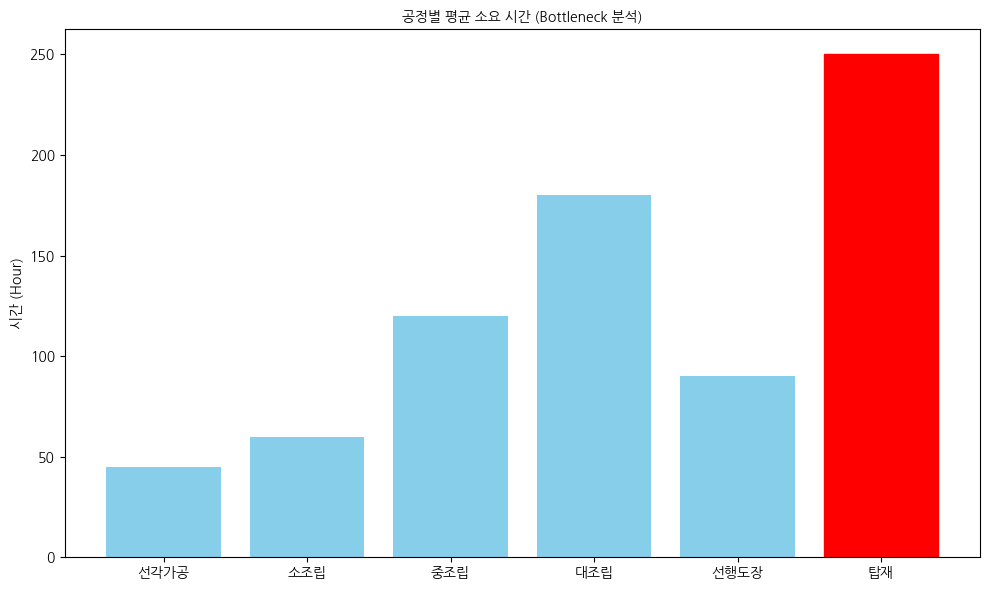

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ✅ 코랩용 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print(f"✅ 폰트 설정 완료: {font_name}")
file="/content/drive/MyDrive/Colab Notebooks/미래혁신인재양성과정/projectlab/공정데이터.xlsx"
# 1. 엑셀 파일로부터 학습 데이터 불러오기
try:
    df = pd.read_excel(file)
    print("✅ 데이터를 성공적으로 불러왔습니다.")
    print(df.head())
except FileNotFoundError:
    print("❌ 파일이 없습니다. '공정데이터.xlsx' 파일명을 확인해주세요.")

# 2. 그래프 그리기
plt.figure(figsize=(10, 6))
bars = plt.bar(df['공정단계'], df['실제시간(h)'], color='skyblue')
bars[5].set_color('red')  # 가장 오래 걸리는 '탑재' 공정 강조

plt.title("공정별 평균 소요 시간 (Bottleneck 분석)", fontproperties=font_prop)
plt.ylabel("시간 (Hour)", fontproperties=font_prop)

# ✅ 축 레이블에도 폰트 명시 적용
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font_prop)

plt.tight_layout()
plt.show()

#[예측] 선박 주요 치수 기반 중량 예측
* L, B, D(선박 제원)를 입력하면 예상되는 총 강재 중량을 자동으로 계산해주는 프로그램.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. 엑셀 파일로부터 학습 데이터 불러오기
file="/content/drive/MyDrive/Colab Notebooks/미래혁신인재양성과정/projectlab/선박데이터_학습용.xlsx"
try:
    # 엑셀 파일을 읽어 df(데이터프레임) 변수에 저장
    df = pd.read_excel(file)
    print("✅ 데이터를 성공적으로 불러왔습니다.")
   # print(df.head()) # 데이터 상단 5줄 출력하여 확인
except FileNotFoundError:
    print("❌ 파일이 없습니다. '선박데이터_학습용.xlsx' 파일명을 확인해주세요.")

# 2. AI 모델 학습을 위한 입력 데이터(X)와 정답 데이터(y) 분리
# 입력값(X): 길이(L), 폭(B), 깊이(D)
# 결과값(y): 강재중량(Weight)
X = df[['길이(L)', '폭(B)', '깊이(D)']]
y = df['강재중량(Weight)']

# 3. 선형 회귀(Linear Regression) 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)
print("\n🤖 AI 모델 학습 완료!")

# 4. 새로운 선박 제원을 입력하여 중량 예측하기
# 예: 길이 220m, 폭 35m, 깊이 21m인 선박의 중량은?
# 경고를 제거하기 위해 predict 입력도 DataFrame 형태로 변경
new_ship_specs_data = [[220, 35, 21]]
new_ship_specs_df = pd.DataFrame(new_ship_specs_data, columns=X.columns) # X의 컬럼명 사용
predicted_weight = model.predict(new_ship_specs_df)

print("-" * 40)
print(f"🚢 입력 제원: L={new_ship_specs_data[0][0]}, B={new_ship_specs_data[0][1]}, D={new_ship_specs_data[0][2]}")
print(f"⚖️ 예측된 강재 중량: 약 {predicted_weight[0]:.2f} 톤")
print("-" * 40)

# 5. (추가) 예측 결과를 엑셀로 저장하기
# 학습 데이터 뒤에 예측값을 붙여서 확인해보고 싶을 때 사용
df['AI_예측중량'] = model.predict(X)
df.to_excel("선박중량_예측결과_리포트.xlsx", index=False)
print("📊 전체 데이터에 대한 예측 리포트가 저장되었습니다.")

✅ 데이터를 성공적으로 불러왔습니다.

🤖 AI 모델 학습 완료!
----------------------------------------
🚢 입력 제원: L=220, B=35, D=21
⚖️ 예측된 강재 중량: 약 11489.71 톤
----------------------------------------
📊 전체 데이터에 대한 예측 리포트가 저장되었습니다.
